# 🔬 Lean re-run notebook — only the cells needed for 3 results

This keeps **only** the cells required to rebuild the state your 3 target diagnostics depend on, then runs the 3 diagnostics themselves. Everything not on that dependency path — old superseded data-loading (SECTION 6.x), diagnostics you already confirmed (confusion matrices, zero-shot check), PART 17–23, PART 18 rigor follow-ups, and all of PART 19 (production/config/docker/tests/etc.) — has been dropped.

**Dependency chain kept (in this order):**
1. Install deps → Config → working dir → clone repo → import libs
2. Load CLIP model
3. Load & prep the (fixed) dataset → `aggregated_annotations`, splits, `Multi3HateDataset`
4. Define debiasing model/trainer classes
5. Hyperparameter search → `best_config`, loaders, class weights
6. Train the proposed (adversarial) model → `trainer`
7. Evaluate on test set → `test_metrics`
8. Train the true baseline → `baseline_results`

**Then the 3 targets:**
- McNemar's + paired t-test + Wilcoxon
- 5-Fold Stratified Group CV
- Memotion external validation

⚠️ Note: step 5 (hyperparameter search) still trains ~27 short model configs, and step 6 trains the full final model — these are genuinely required to produce `best_config` and `trainer`, there's no way around re-running them if the upstream dataset changed. This notebook just removes everything *else* that wasn't on the path to your 3 results.

---
## Part A — Rebuilding required state

### 1.1 Install Dependencies

In [2]:
# ============================================================
# MULTI3HATE DEBIASING - KAGGLE NOTEBOOK
# For "Debiasing Vision-Language Models for Culturally-Aware
# Multimodal Hate Speech Detection"
# ============================================================

#@title 1. Install Dependencies
#@markdown Run this cell first to install extra packages.
#@markdown NOTE: Kaggle's GPU image already ships a working
#@markdown torch+CUDA build, so we do NOT reinstall torch here
#@markdown (forcing --index-url cu118 can break the preinstalled
#@markdown CUDA setup). Make sure "Internet" is switched ON and a
#@markdown "GPU" accelerator (T4 x2 / P100) is selected under
#@markdown Notebook Settings (right sidebar) before running.

!pip install -q transformers==4.37.2
!pip install -q datasets pillow matplotlib seaborn scikit-learn
!pip install -q open-clip-torch
!pip install -q accelerate
!pip install -q wandb
!pip install -q gradio
!pip install -q huggingface-hub

import torch
print("✅ All dependencies installed successfully!")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
sentence-transformers 5.7.0 requires tokenizers>=0.19, but you have tokenizers 0.15.2 which is incompatible.
sentence-transformers 5.7.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5

### 1.2 Config

In [3]:
from dataclasses import dataclass

@dataclass
class Config:

    # Data
    BATCH_SIZE = 16
    NUM_WORKERS = 0

    # Model
    HIDDEN_DIM = 256
    FEATURE_DIM = 1024 # Original: clip_model.feature_dim * 2

    # Training
    LEARNING_RATE = 1e-4
    NUM_EPOCHS = 30
    PATIENCE = 5

    # Adversarial Learning
    LAMBDA_ADV = 0.1
    LAMBDA_SCHEDULE = "sigmoid"

    # Randomness
    SEED = 42

config = Config()

### 1.3 Setup Working Directory (Kaggle)

In [4]:
#@title 1. Setup Working Directory (Kaggle)
#@markdown Kaggle notebooks don't use Google Drive. We just use the
#@markdown always-available, persisted-with-the-notebook directory
#@markdown /kaggle/working instead.

import os
import sys

# Create base working directory
os.makedirs('/kaggle/working/Multi3Hate', exist_ok=True)

# Change to working directory
%cd /kaggle/working/Multi3Hate

print("✅ Working directory created at /kaggle/working/Multi3Hate")
print("📁 Current directory:", os.getcwd())


/kaggle/working/Multi3Hate
✅ Working directory created at /kaggle/working/Multi3Hate
📁 Current directory: /kaggle/working/Multi3Hate


### 1.4 Clone Repository

In [5]:
#@title 2. Clone Repository
#@markdown Clone the official Multi3Hate repository.
#@markdown Requires Internet to be switched ON in Notebook Settings.

import subprocess

# Clone repository
if not os.path.exists('/kaggle/working/Multi3Hate/.git'):
    print("Cleaning working directory before cloning...")
    !rm -rf /kaggle/working/Multi3Hate/* # Ensure the directory is empty for cloning
    !git clone https://github.com/MinhDucBui/Multi3Hate.git .
    print("✅ Repository cloned successfully!")
else:
    print("✅ Repository already exists!")

# Create output working directories (models, results, figures) after cloning
os.makedirs('/kaggle/working/Multi3Hate/models', exist_ok=True)
os.makedirs('/kaggle/working/Multi3Hate/results', exist_ok=True)
os.makedirs('/kaggle/working/Multi3Hate/figures', exist_ok=True)

# List files
print("\n📂 Repository structure:")
!ls -la


Cleaning working directory before cloning...
Cloning into '.'...
remote: Enumerating objects: 1800, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 1800 (delta 6), reused 9 (delta 2), pack-reused 1772 (from 1)
Receiving objects: 100% (1800/1800), 54.93 MiB | 33.15 MiB/s, done.
Resolving deltas: 100% (190/190), done.
✅ Repository cloned successfully!

📂 Repository structure:
total 44
drwxr-xr-x 8 root root 4096 Sep  6 16:58 .
drwxr-xr-x 3 root root 4096 Sep  6 16:58 ..
drwxr-xr-x 4 root root 4096 Sep  6 16:58 data
drwxr-xr-x 2 root root 4096 Sep  6 16:58 figures
drwxr-xr-x 8 root root 4096 Sep  6 16:58 .git
-rw-r--r-- 1 root root 3148 Sep  6 16:58 .gitignore
drwxr-xr-x 2 root root 4096 Sep  6 16:58 models
-rw-r--r-- 1 root root 1730 Sep  6 16:58 README.md
-rw-r--r-- 1 root root 1455 Sep  6 16:58 requirements.txt
drwxr-xr-x 2 root root 4096 Sep  6 16:58 results
drwxr-xr-x 5 root root 4096 Sep  6 16:58 vlm


### 1.5 Import Libraries

In [6]:
#@title 3. Import Libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Fix for huggingface-hub version conflict
# Upgrade huggingface-hub to a version that includes '_xet_progress_reporting' and is compatible with transformers==4.37.2
!pip install -q huggingface-hub==0.22.0 --force-reinstall

import transformers
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset
import open_clip

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 180.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.5/388.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.6/250.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### 2. Load CLIP Model

In [7]:
#@title 8. Load CLIP Model (Alternative - OpenCLIP)

!pip install -q open-clip-torch

import torch
import open_clip
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

class CLIPModelWrapper:
    """Wrapper for CLIP model using OpenCLIP (more robust)"""

    def __init__(self, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Loading OpenCLIP model: {model_name}")
        print(f"Pretrained: {pretrained}")
        print(f"Device: {self.device}")

        try:
            # Load model
            self.model, _, self.preprocess = open_clip.create_model_and_transforms(
                model_name=model_name,
                pretrained=pretrained
            )
            self.model = self.model.to(self.device)

            # Get tokenizer
            self.tokenizer = open_clip.get_tokenizer(model_name)

            # Get feature dimension
            self.feature_dim = self.model.visual.output_dim if hasattr(self.model.visual, 'output_dim') else 512

            print("✅ OpenCLIP model loaded successfully!")
            print(f"   Feature dimension: {self.feature_dim}")
            self.is_openclip = True

        except Exception as e:
            print(f"❌ Error loading OpenCLIP: {e}")
            # Create dummy
            self.feature_dim = 512
            self.is_dummy = True
            print("⚠️ Using dummy model (for demonstration only)")

    def get_features(self, images, texts):
        """Extract features from CLIP"""
        if hasattr(self, 'is_dummy'):
            # Determine batch_size from images, assuming it's a tensor or list
            batch_size = images.shape[0] if isinstance(images, torch.Tensor) else (len(images) if isinstance(images, list) else 1)
            return torch.randn(batch_size, self.feature_dim * 2).to(self.device) # Ensure dummy features are on device

        try:
            # Handle images: can be a preprocessed tensor batch from DataLoader, or PIL images (single or list)
            if isinstance(images, torch.Tensor):
                # Images are already preprocessed [B, C, H, W] tensor from DataLoader
                image_tensor = images.to(self.device)
            elif isinstance(images, list): # List of PIL Images
                image_tensors = [self.preprocess(img) for img in images] # preprocess each PIL image
                image_tensor = torch.stack(image_tensors, dim=0).to(self.device) # stack into a batch [B, C, H, W]
            elif isinstance(images, Image.Image): # Single PIL Image
                image_tensor = self.preprocess(images).unsqueeze(0).to(self.device) # preprocess and add batch dim
            else:
                raise ValueError(f"Unsupported image input type: {type(images)}")

            # Handle texts: can be a list of strings (from DataLoader) or a single string
            if isinstance(texts, (list, tuple)): # Batch of texts from DataLoader (list of strings)
                text_tokens = self.tokenizer(texts).to(self.device)
            elif isinstance(texts, str): # Single text string
                text_tokens = self.tokenizer([texts]).to(self.device)
            else:
                raise ValueError(f"Unsupported text input type: {type(texts)}")

            with torch.no_grad():
                image_features = self.model.encode_image(image_tensor)
                text_features = self.model.encode_text(text_tokens)

                # Normalize
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

                combined_features = torch.cat([image_features, text_features], dim=1)

            return combined_features

        except Exception as e:
            # Fallback for errors during feature extraction, try to make a dummy tensor of correct batch size
            print(f"⚠️ Error extracting features: {e}")
            batch_size = images.shape[0] if isinstance(images, torch.Tensor) else (len(images) if isinstance(images, list) else 1)
            return torch.randn(batch_size, self.feature_dim * 2).to(self.device)

# Initialize CLIP
try:
    clip_model = CLIPModelWrapper()
except Exception as e:
    print(f"❌ Failed to initialize CLIP: {e}")
    print("Creating dummy CLIP wrapper...")
    clip_model = CLIPModelWrapper(model_name='dummy', pretrained='dummy')

# Test
print("\nTesting CLIP model...")
try:
    from PIL import Image
    dummy_image = Image.new('RGB', (224, 224), color='white')
    dummy_text = "test image"

    features = clip_model.get_features([dummy_image], [dummy_text])
    print(f"✅ Feature extraction working! Shape: {features.shape}")
except Exception as e:
    print(f"⚠️ Feature extraction test failed: {e}")

print("\n✅ CLIP model ready!")

Loading OpenCLIP model: ViT-B-32
Pretrained: laion2b_s34b_b79k
Device: cuda


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ OpenCLIP model loaded successfully!
   Feature dimension: 512

Testing CLIP model...
✅ Feature extraction working! Shape: torch.Size([1, 1024])

✅ CLIP model ready!


### 3. Load & Prep Dataset (fixed) — aggregated_annotations, splits, Multi3HateDataset

In [8]:
# ============================================================
# REPLACEMENT for cells "9. Aggregate Raw Annotations" and
# "10 (data loading portion of cell 21)" — uses real captions/
# final_annotations.csv instead of the broken meme_id-as-filename
# reconstruction that produced blank images + placeholder text.
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from PIL import Image

MEME_DIR = '/kaggle/working/Multi3Hate/data/memes'
CAPTIONS_DIR = '/kaggle/working/Multi3Hate/data/captions'
CULTURE_TO_LANG = {'US': 'en', 'DE': 'de', 'MX': 'es', 'CN': 'zh', 'IN': 'hi'}

# ---- 1. meme_id -> template folder, built by scanning disk (folder names
#         don't derive cleanly from Template Name text, so don't guess it) ----
folder_lookup = {}
for template_folder in os.listdir(f"{MEME_DIR}/en"):
    template_path = os.path.join(f"{MEME_DIR}/en", template_folder)
    if not os.path.isdir(template_path):
        continue
    for fname in os.listdir(template_path):
        if fname.lower().endswith('.jpg'):
            folder_lookup[int(os.path.splitext(fname)[0])] = template_folder

# ---- 2. Real per-language captions, <sep> cleaned up ----
caption_frames = []
for culture, lang in CULTURE_TO_LANG.items():
    df = pd.read_csv(f'{CAPTIONS_DIR}/{lang}.csv')
    df['culture'] = culture
    df['language'] = lang
    df['clean_text'] = df['Translation'].fillna('').str.replace('<sep>', ' ', regex=False).str.strip()
    caption_frames.append(df[['Meme ID', 'culture', 'language', 'clean_text']])
captions_long = pd.concat(caption_frames, ignore_index=True).rename(columns={'Meme ID': 'meme_id'})

# ---- 3. Real aggregated ground-truth labels (already majority-voted) ----
final_annotations = pd.read_csv('/kaggle/working/Multi3Hate/data/final_annotations.csv')
labels_long = final_annotations.melt(
    id_vars='Meme ID', value_vars=list(CULTURE_TO_LANG.keys()),
    var_name='culture', value_name='label'
).rename(columns={'Meme ID': 'meme_id'})

# ---- 4. Join labels + captions + real image path ----
aggregated_annotations = labels_long.merge(captions_long, on=['meme_id', 'culture'], how='left')
aggregated_annotations['template_folder'] = aggregated_annotations['meme_id'].map(folder_lookup)
aggregated_annotations['image_path'] = aggregated_annotations.apply(
    lambda r: f"{MEME_DIR}/{r['language']}/{r['template_folder']}/{r['meme_id']}.jpg", axis=1
)
aggregated_annotations = aggregated_annotations.rename(columns={'clean_text': 'original_text'})

# ---- 5. Validate before doing anything else ----
n_missing_img = (~aggregated_annotations['image_path'].apply(os.path.exists)).sum()
n_empty_text = (aggregated_annotations['original_text'].str.len() == 0).sum()
n_dup_text = (aggregated_annotations.groupby('meme_id')['original_text'].nunique() == 1).sum()
print(f"Rows: {len(aggregated_annotations)} | Missing images: {n_missing_img} | "
      f"Empty text: {n_empty_text} | Memes with duplicate text across cultures: {n_dup_text}")
assert n_missing_img == 0 and n_empty_text == 0 and n_dup_text == 0, \
    "Validation failed — do not proceed to feature extraction until this is clean."

GLOBAL_CULTURE_TO_IDX = {c: i for i, c in enumerate(sorted(aggregated_annotations['culture'].unique()))}


# ---- 6. Corrected Dataset class — reads precomputed path/text, no reconstruction ----
class Multi3HateDataset(Dataset):
    """Multi3Hate dataset built on real per-culture captions + real image paths."""

    def __init__(self, annotations_df, transform=None, culture_to_idx=None):
        self.annotations = annotations_df.reset_index(drop=True)
        self.transform = transform
        self.culture_to_idx = culture_to_idx or GLOBAL_CULTURE_TO_IDX
        self.idx_to_culture = {i: c for c, i in self.culture_to_idx.items()}

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        try:
            image = Image.open(row['image_path']).convert('RGB')
        except Exception as e:
            print(f"⚠️ Failed to load {row['image_path']}: {e}")
            image = Image.new('RGB', (224, 224), color='white')

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'text': row['original_text'],
            'label': torch.tensor(int(row['label']), dtype=torch.long),
            'culture': row['culture'],
            'culture_idx': torch.tensor(self.culture_to_idx.get(row['culture'], 0), dtype=torch.long),
            'meme_id': row['meme_id'],
            'language': row['language'],
        }

    # keep meme_dir attribute name alive for any older cells (e.g. 13b) that
    # still reference dataset.meme_dir
    meme_dir = MEME_DIR


# ---- 7. Group split by meme_id (unchanged logic, now on real data) ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss.split(aggregated_annotations, groups=aggregated_annotations['meme_id']))
train_data = aggregated_annotations.iloc[train_idx]
temp_data = aggregated_annotations.iloc[temp_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_data, groups=temp_data['meme_id']))
val_data = temp_data.iloc[val_idx]
test_data = temp_data.iloc[test_idx]

assert set(train_data['meme_id']).isdisjoint(set(val_data['meme_id']))
assert set(train_data['meme_id']).isdisjoint(set(test_data['meme_id']))
assert set(val_data['meme_id']).isdisjoint(set(test_data['meme_id']))

dataset = Multi3HateDataset(aggregated_annotations, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
train_dataset = Multi3HateDataset(train_data, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
val_dataset = Multi3HateDataset(val_data, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
test_dataset = Multi3HateDataset(test_data, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)

print("✅ Dataset split complete on CORRECTED data (real images + real per-culture text)!")
print(f"   Training:   {len(train_dataset)} samples ({train_data['meme_id'].nunique()} unique memes)")
print(f"   Validation: {len(val_dataset)} samples ({val_data['meme_id'].nunique()} unique memes)")
print(f"   Test:       {len(test_dataset)} samples ({test_data['meme_id'].nunique()} unique memes)")
print(f"   Cultures:   {GLOBAL_CULTURE_TO_IDX}")

Rows: 1500 | Missing images: 0 | Empty text: 0 | Memes with duplicate text across cultures: 0
✅ Dataset split complete on CORRECTED data (real images + real per-culture text)!
   Training:   1050 samples (210 unique memes)
   Validation: 225 samples (45 unique memes)
   Test:       225 samples (45 unique memes)
   Cultures:   {'CN': 0, 'DE': 1, 'IN': 2, 'MX': 3, 'US': 4}


### 4. Define Debiasing Model & Trainer classes

In [9]:
#@title 10. Define Debiasing Models — FIX: proper Gradient Reversal Layer, AMP, early stopping, grad clipping, class weights, lambda scheduling, grad accumulation
import copy
import numpy as np
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight


def compute_class_weights_tensor(labels, num_classes=None, device='cpu'):
    """FIX (data imbalance): inverse-frequency ('balanced') class weights for
    CrossEntropyLoss, so the minority class isn't drowned out by the majority
    class during training."""
    labels = np.asarray(labels)
    classes = np.arange(num_classes) if num_classes is not None else np.unique(labels)
    present = np.unique(labels)
    weights = np.ones(len(classes), dtype=np.float32)
    if len(present) > 1:
        balanced = compute_class_weight('balanced', classes=present, y=labels)
        for c, w in zip(present, balanced):
            weights[int(c)] = w
    return torch.tensor(weights, dtype=torch.float32, device=device)


class GradientReversalFunction(torch.autograd.Function):
    """Identity in the forward pass; negates (and scales by lambda) the gradient
    on the backward pass. This is what makes adversarial debiasing actually work:
    the shared encoder is pushed to produce features the adversary CANNOT use to
    predict culture, because it receives the *negated* adversary gradient."""

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)


class AdversarialDebiasingModel(nn.Module):
    """A small trainable shared encoder sits on top of the frozen CLIP features.
    The hate-speech classifier and the culture adversary both read from this
    SAME shared representation, and the adversary path goes through a Gradient
    Reversal Layer. This is what lets the classifier learn a representation
    that is predictive of hate speech but NOT predictive of culture — the
    previous version detached the adversary's input, so no debiasing signal
    could ever reach the shared representation.
    """

    def __init__(self, feature_dim, num_classes=2, num_cultures=5,
                 hidden_dim=256, dropout=0.3, lambda_adv=0.1):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

        self.grl = GradientReversalLayer(lambda_adv)
        self.adversary = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_cultures),
        )

    def set_lambda(self, lambda_adv):
        self.grl.lambda_ = lambda_adv

    def forward(self, features, return_features=False):
        shared = self.encoder(features)
        hate_logits = self.classifier(shared)
        culture_logits = self.adversary(self.grl(shared))

        if return_features:
            return hate_logits, culture_logits, shared
        return hate_logits, culture_logits


class AdversarialTrainer:
    """Trainer with proper adversarial debiasing (via GRL), mixed precision,
    gradient clipping, early stopping with checkpointing, class-weighted
    losses, gradient-reversal lambda scheduling, and gradient accumulation."""

    def __init__(self, model, backbone, device, lambda_adv=0.1, learning_rate=1e-4,
                 weight_decay=1e-4, max_grad_norm=1.0,
                 hate_class_weights=None, culture_class_weights=None,
                 lambda_schedule='constant', accum_steps=1):
        self.model = model.to(device)
        self.backbone = backbone
        self.device = device

        # lambda_adv is treated as the SCHEDULE TARGET (lambda_max); the
        # effective value used each epoch is set by `_scheduled_lambda`.
        self.lambda_max = lambda_adv
        self.lambda_schedule = lambda_schedule  # 'constant' | 'linear' | 'sigmoid'
        self.lambda_adv = lambda_adv if lambda_schedule == 'constant' else 0.0
        self.model.set_lambda(self.lambda_adv)

        self.max_grad_norm = max_grad_norm
        self.accum_steps = max(1, accum_steps)

        # FIX: train encoder + classifier + adversary jointly. Because the GRL
        # already flips the adversary's gradient, we can simply ADD the two
        # losses — no manual "minus lambda * loss" needed (that pattern from
        # the previous version doesn't achieve a min-max game when the
        # adversary's input is detached).
        self.optimizer = AdamW(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=50)

        # FIX (data imbalance): optional class weights on both losses.
        self.hate_loss_fn = nn.CrossEntropyLoss(
            weight=hate_class_weights.to(device) if hate_class_weights is not None else None
        )
        self.culture_loss_fn = nn.CrossEntropyLoss(
            weight=culture_class_weights.to(device) if culture_class_weights is not None else None
        )

        self.use_amp = torch.cuda.is_available()
        self.scaler = GradScaler('cuda', enabled=self.use_amp)

        self.history = {
            'hate_loss': [], 'adv_loss': [], 'total_loss': [],
            'hate_acc': [], 'adv_acc': [], 'lambda_adv': [],
            'val_hate_loss': [], 'val_hate_acc': [],
            # DIAGNOSTIC (collapse detection): fraction of predictions that
            # are the positive ('hate') class, on train and val each epoch.
            # If this pins near 0.0 or 1.0 for most of training, the model
            # has collapsed to a constant-output classifier and val_hate_loss
            # / val_hate_acc alone will NOT reveal it.
            'train_pred_pos_rate': [], 'val_pred_pos_rate': [],
        }

    def _scheduled_lambda(self, progress):
        """DANN-style (Ganin & Lempitsky, 2015) schedule: ramping lambda from 0
        up to lambda_max avoids the adversary dominating early training, when
        the shared representation is still poor and adversary gradients are
        noisy/large. progress in [0, 1] is the fraction of training elapsed."""
        if self.lambda_schedule == 'constant':
            return self.lambda_max
        elif self.lambda_schedule == 'linear':
            return self.lambda_max * progress
        elif self.lambda_schedule == 'sigmoid':
            return self.lambda_max * (2.0 / (1.0 + np.exp(-10.0 * progress)) - 1.0)
        else:
            raise ValueError(f"Unknown lambda_schedule: {self.lambda_schedule}")

    def _get_features(self, batch):
        with torch.no_grad():
            return self.backbone.get_features(batch['image'], batch['text'])

    def train_epoch(self, dataloader):
        self.model.train()
        total_hate_loss, total_adv_loss, total_combined_loss = 0.0, 0.0, 0.0
        all_hate_preds, all_hate_labels = [], []
        all_culture_preds, all_culture_labels = [], []

        n_batches = len(dataloader)
        self.optimizer.zero_grad()

        for i, batch in enumerate(tqdm(dataloader, desc="Training")):
            features = self._get_features(batch)
            hate_labels = batch['label'].to(self.device)
            culture_labels = batch['culture_idx'].to(self.device)
            microbatch_size = hate_labels.size(0)

            with autocast('cuda', enabled=self.use_amp):
                hate_logits, culture_logits = self.model(features)
                hate_loss = self.hate_loss_fn(hate_logits, hate_labels)
                culture_loss = self.culture_loss_fn(culture_logits, culture_labels)
                # GRL already negates the adversary's gradient contribution to
                # the shared encoder, so a simple sum implements the min-max
                # adversarial objective correctly.
                combined_loss = hate_loss + culture_loss
                # FIX (gradient accumulation): scale down so that accumulating
                # `accum_steps` microbatches approximates one larger-batch step.
                scaled_loss = combined_loss / self.accum_steps

            self.scaler.scale(scaled_loss).backward()

            is_last_batch = (i + 1) == n_batches
            if (i + 1) % self.accum_steps == 0 or is_last_batch:
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad()

            total_hate_loss += hate_loss.item()
            total_adv_loss += culture_loss.item()
            total_combined_loss += combined_loss.item()

            all_hate_preds.extend(hate_logits.argmax(dim=1).detach().cpu().numpy())
            all_hate_labels.extend(hate_labels.cpu().numpy())
            all_culture_preds.extend(culture_logits.argmax(dim=1).detach().cpu().numpy())
            all_culture_labels.extend(culture_labels.cpu().numpy())

        self.scheduler.step()

        n = len(dataloader)
        hate_acc = accuracy_score(all_hate_labels, all_hate_preds)
        adv_acc = accuracy_score(all_culture_labels, all_culture_preds)
        # DIAGNOSTIC: fraction of TRAIN predictions that are class 1 ('hate').
        train_pred_pos_rate = float(np.mean(all_hate_preds)) if len(all_hate_preds) else float('nan')

        self.history['hate_loss'].append(total_hate_loss / n)
        self.history['adv_loss'].append(total_adv_loss / n)
        self.history['total_loss'].append(total_combined_loss / n)
        self.history['hate_acc'].append(hate_acc)
        self.history['adv_acc'].append(adv_acc)
        self.history['lambda_adv'].append(self.lambda_adv)
        self.history['train_pred_pos_rate'].append(train_pred_pos_rate)

        return {
            'hate_loss': total_hate_loss / n, 'adv_loss': total_adv_loss / n,
            'total_loss': total_combined_loss / n, 'hate_acc': hate_acc, 'adv_acc': adv_acc,
        }

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        all_hate_preds, all_hate_labels = [], []
        all_culture_preds, all_culture_labels, all_cultures = [], [], []
        total_hate_loss = 0.0

        for batch in tqdm(dataloader, desc="Evaluating"):
            features = self._get_features(batch)
            hate_logits, culture_logits = self.model(features)

            hate_labels = batch['label'].to(self.device)
            total_hate_loss += self.hate_loss_fn(hate_logits, hate_labels).item()

            all_hate_preds.extend(hate_logits.argmax(dim=1).cpu().numpy())
            all_hate_labels.extend(batch['label'].numpy())
            all_culture_preds.extend(culture_logits.argmax(dim=1).cpu().numpy())
            all_culture_labels.extend(batch['culture_idx'].numpy())
            all_cultures.extend(batch['culture'])

        hate_acc = accuracy_score(all_hate_labels, all_hate_preds)
        adv_acc = accuracy_score(all_culture_labels, all_culture_preds)

        culture_results = {}
        for culture in set(all_cultures):
            mask = np.array(all_cultures) == culture
            if mask.sum() > 0:
                culture_results[culture] = accuracy_score(
                    np.array(all_hate_labels)[mask], np.array(all_hate_preds)[mask]
                )

        return {
            'hate_loss': total_hate_loss / max(len(dataloader), 1),
            'hate_acc': hate_acc,
            'adv_acc': adv_acc,
            'culture_results': culture_results,
            'predictions': all_hate_preds,
            'labels': all_hate_labels,
        }

    def fit(self, train_loader, val_loader, num_epochs=30, patience=5,
            checkpoint_path='/kaggle/working/Multi3Hate/models/best_model.pt', verbose=True):
        """FIX: early stopping on validation hate-loss + checkpointing of the
        best model (previous version only trained a fixed number of epochs
        and saved whatever the final weights happened to be)."""
        best_val_loss = float('inf')
        best_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):
            # FIX (lambda scheduling): ramp lambda_adv according to self.lambda_schedule.
            progress = epoch / max(num_epochs - 1, 1)
            self.lambda_adv = self._scheduled_lambda(progress)
            self.model.set_lambda(self.lambda_adv)

            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.evaluate(val_loader)
            self.history['val_hate_loss'].append(val_metrics['hate_loss'])
            self.history['val_hate_acc'].append(val_metrics['hate_acc'])
            # DIAGNOSTIC: fraction of VAL predictions that are class 1 ('hate').
            val_preds = val_metrics.get('predictions', [])
            val_pred_pos_rate = float(np.mean(val_preds)) if len(val_preds) else float('nan')
            self.history['val_pred_pos_rate'].append(val_pred_pos_rate)

            if verbose:
                print(f"Epoch {epoch + 1}/{num_epochs} (lambda_adv={self.lambda_adv:.4f}): "
                      f"train_hate_loss={train_metrics['hate_loss']:.4f} "
                      f"train_hate_acc={train_metrics['hate_acc']:.3f} "
                      f"adv_acc={train_metrics['adv_acc']:.3f} | "
                      f"val_hate_loss={val_metrics['hate_loss']:.4f} "
                      f"val_hate_acc={val_metrics['hate_acc']:.3f} | "
                      f"train_pos_rate={self.history['train_pred_pos_rate'][-1]:.3f} "
                      f"val_pos_rate={val_pred_pos_rate:.3f}")

            if val_metrics['hate_loss'] < best_val_loss - 1e-4:
                best_val_loss = val_metrics['hate_loss']
                best_state = copy.deepcopy(self.model.state_dict())
                epochs_without_improvement = 0
                os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
                torch.save(best_state, checkpoint_path)
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    if verbose:
                        print(f"⏹ Early stopping at epoch {epoch + 1} "
                              f"(no val improvement for {patience} epochs). "
                              f"Best val_hate_loss={best_val_loss:.4f}")
                    break

        if best_state is not None:
            self.model.load_state_dict(best_state)
            if verbose:
                print(f"✅ Restored best checkpoint (val_hate_loss={best_val_loss:.4f})")

        return self.history


# Initialize the debiasing model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
debiasing_model = AdversarialDebiasingModel(
    feature_dim=clip_model.feature_dim * 2,
    num_classes=2,
    num_cultures=len(GLOBAL_CULTURE_TO_IDX),
    lambda_adv=0.1,
)

print(f"✅ Adversarial debiasing model initialized on {device}")
print(f"   Trainable parameters: {sum(p.numel() for p in debiasing_model.parameters() if p.requires_grad):,}")


✅ Adversarial debiasing model initialized on cuda
   Trainable parameters: 329,095


### 5. Hyperparameter Search — best_config, loaders, class weights

In [10]:
import itertools

param_grid = {
    'learning_rate': [config.LEARNING_RATE * 10, config.LEARNING_RATE / 10, config.LEARNING_RATE],
    'hidden_dim': [config.HIDDEN_DIM // 2, config.HIDDEN_DIM, config.HIDDEN_DIM * 2],
    'lambda_adv': [config.LAMBDA_ADV / 2, config.LAMBDA_ADV, config.LAMBDA_ADV * 2]
}

batch_size = config.BATCH_SIZE

# FIX (Colab DataLoader crash): num_workers > 0 spawns worker processes that
# must pickle the Dataset. On Colab this frequently crashes with
# "DataLoader worker (pid ...) is killed by signal" (shared-memory /dev/shm
# is small) or a PicklingError if the Dataset holds any reference to a model,
# lambda, or local function. Default to 0 (safe, in-process loading) unless
# you've verified your Dataset only holds plain tensors/arrays.
_num_workers = 0
_pin_memory = torch.cuda.is_available()
_persistent_workers = _num_workers > 0  # only valid when num_workers > 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                           num_workers=_num_workers, pin_memory=_pin_memory,
                           persistent_workers=_persistent_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=_num_workers, pin_memory=_pin_memory,
                         persistent_workers=_persistent_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=_num_workers, pin_memory=_pin_memory,
                          persistent_workers=_persistent_workers)

# FIX (data imbalance): class weights computed once from the TRAINING split
# only (never from val/test, to avoid leaking their label distribution), then
# reused by every trainer in the notebook (search, final model, baseline, CV,
# ablation) so all comparisons are made under the same weighting scheme.
train_hate_class_weights = compute_class_weights_tensor(train_data['label'].values, num_classes=2)
train_culture_labels = train_data['culture'].map(GLOBAL_CULTURE_TO_IDX).values
train_culture_class_weights = compute_class_weights_tensor(train_culture_labels, num_classes=len(GLOBAL_CULTURE_TO_IDX))

print("⚖️ Class weights (balanced, from training split only):")
print(f"   Hate label weights:    {train_hate_class_weights.tolist()}")
print(f"   Culture label weights: {train_culture_class_weights.tolist()}")

# Effective batch size = batch_size * ACCUM_STEPS via gradient accumulation
# (see AdversarialTrainer/BaselineTrainer). Kept modest here since hyperparameter
# trials are short; the final model below uses a larger effective batch.
ACCUM_STEPS_FINAL = 2

search_results = []
combos = list(itertools.product(param_grid['learning_rate'], param_grid['hidden_dim'], param_grid['lambda_adv']))
print(f"\n🔍 Searching {len(combos)} hyperparameter combinations (short runs, early stopping)...")

for lr, hidden_dim, lambda_adv in combos:
    torch.manual_seed(42)
    model = AdversarialDebiasingModel(
        feature_dim=clip_model.feature_dim * 2,
        num_classes=2,
        num_cultures=len(GLOBAL_CULTURE_TO_IDX),
        hidden_dim=hidden_dim,
        lambda_adv=lambda_adv,
    )
    # FIX (search/final mismatch): trials previously used lambda_schedule=
    # 'constant', which fights the encoder from epoch 1 and produced near-
    # chance val accuracy (~0.45-0.56) for every combo in the search. The
    # final model (PART 12) uses 'sigmoid' ramp-up. Matching that here makes
    # the search results actually predictive of final-model performance.
    trial_trainer = AdversarialTrainer(
        model=model, backbone=clip_model, device=device,
        lambda_adv=lambda_adv, learning_rate=lr, lambda_schedule='sigmoid',
        hate_class_weights=train_hate_class_weights,
        culture_class_weights=train_culture_class_weights,
    )
    # FIX (convergence): 8 epochs / patience=3 was cutting trials off before
    # the encoder had a chance to learn anything useful under the ramp-up
    # schedule. Bumped modestly — still cheap relative to final training.
    try:
        trial_trainer.fit(train_loader, val_loader, num_epochs=12, patience=4,
                           checkpoint_path='/kaggle/working/Multi3Hate/models/tuning_tmp.pt',
                           verbose=False)
        val_metrics = trial_trainer.evaluate(val_loader)
    except RuntimeError as e:
        # FIX (graceful degradation): one bad combo (e.g. OOM at hidden_dim=256)
        # shouldn't kill the whole search — skip it and keep going.
        print(f"  ⚠️ Skipping lr={lr}, hidden={hidden_dim}, lambda_adv={lambda_adv} "
              f"— {type(e).__name__}: {e}")
        continue

    accs = list(val_metrics['culture_results'].values())
    bias_gap = (max(accs) - min(accs)) if accs else float('nan')

    search_results.append({
        'learning_rate': lr, 'hidden_dim': hidden_dim, 'lambda_adv': lambda_adv,
        'val_hate_acc': val_metrics['hate_acc'], 'val_adv_acc': val_metrics['adv_acc'],
        'val_bias_gap': bias_gap,
    })
    print(f"  lr={lr:<7} hidden={hidden_dim:<4} lambda_adv={lambda_adv:<5} "
          f"-> val_hate_acc={val_metrics['hate_acc']:.3f}, val_bias_gap={bias_gap:.3f}")

if not search_results:
    raise RuntimeError("All hyperparameter trials failed — check the errors printed above "
                        "before continuing to PART 12.")

search_df = pd.DataFrame(search_results)
# Rank by hate accuracy first, break ties by lower bias gap (fairer model).
search_df = search_df.sort_values(['val_hate_acc', 'val_bias_gap'], ascending=[False, True])
display(search_df)

best_config = search_df.iloc[0].to_dict()
print(f"\n✅ Best config: lr={best_config['learning_rate']}, hidden_dim={int(best_config['hidden_dim'])}, "
      f"lambda_adv={best_config['lambda_adv']} "
      f"(val_hate_acc={best_config['val_hate_acc']:.3f}, val_bias_gap={best_config['val_bias_gap']:.3f})")

⚖️ Class weights (balanced, from training split only):
   Hate label weights:    [1.1513158082962036, 0.8838383555412292]
   Culture label weights: [1.0, 1.0, 1.0, 1.0, 1.0]

🔍 Searching 27 hyperparameter combinations (short runs, early stopping)...


Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.00it/s]


  lr=0.001   hidden=128  lambda_adv=0.05  -> val_hate_acc=0.622, val_bias_gap=0.111


Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.82it/s]


  lr=0.001   hidden=128  lambda_adv=0.1   -> val_hate_acc=0.604, val_bias_gap=0.067


...

  lr=0.0001  hidden=512  lambda_adv=0.1   -> val_hate_acc=0.636, val_bias_gap=0.111


Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.79it/s]

  lr=0.0001  hidden=512  lambda_adv=0.2   -> val_hate_acc=0.640, val_bias_gap=0.178


,learning_rate,hidden_dim,lambda_adv,val_hate_acc,val_adv_acc,val_bias_gap
26,0.00010,512,0.20,0.640000,0.324444,0.177778
24,0.00010,512,0.05,0.635556,0.488889,0.111111
25,0.00010,512,0.10,0.635556,0.417778,0.111111
3,0.00100,256,0.05,0.631111,0.351111,0.111111
7,0.00100,512,0.10,0.626667,0.684444,0.111111
18,0.00010,128,0.05,0.622222,0.324444,0.088889
0,0.00100,128,0.05,0.622222,0.400000,0.111111
8,0.00100,512,0.20,0.622222,0.635556,0.111111
21,0.00010,256,0.05,0.613333,0.435556,0.066667
22,0.00010,256,0.10,0.613333,0.391111,0.066667



✅ Best config: lr=0.0001, hidden_dim=512, lambda_adv=0.2 (val_hate_acc=0.640, val_bias_gap=0.178)


### 6. Train Final (Proposed/Adversarial) Model — trainer

🚀 Starting training with adversarial debiasing (proper GRL)...
   lambda_adv target=0.2 (sigmoid schedule), lr=0.0001, hidden_dim=512, batch_size=16, effective_batch_size=32
   Mixed precision (AMP): True


Evaluating: 100%|██████████| 15/15 [00:05<00:00,  2.71it/s]


Epoch 1/30 (lambda_adv=0.0000): train_hate_loss=0.6933 train_hate_acc=0.560 adv_acc=0.305 | val_hate_loss=0.6931 val_hate_acc=0.569 | train_pos_rate=0.916 val_pos_rate=0.982


Evaluating: 100%|██████████| 15/15 [00:03<00:00,  4.66it/s]


Epoch 2/30 (lambda_adv=0.0341): train_hate_loss=0.6915 train_hate_acc=0.610 adv_acc=0.463 | val_hate_loss=0.6929 val_hate_acc=0.622 | train_pos_rate=0.821 val_pos_rate=0.893


...

Epoch 12/30 (lambda_adv=0.1912): train_hate_loss=0.5319 train_hate_acc=0.768 adv_acc=0.382 | val_hate_loss=0.6743 val_hate_acc=0.622 | train_pos_rate=0.583 val_pos_rate=0.609


Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.91it/s]


Epoch 13/30 (lambda_adv=0.1937): train_hate_loss=0.5127 train_hate_acc=0.776 adv_acc=0.366 | val_hate_loss=0.6689 val_hate_acc=0.627 | train_pos_rate=0.582 val_pos_rate=0.489


Evaluating: 100%|██████████| 15/15 [00:03<00:00,  4.87it/s]

Epoch 14/30 (lambda_adv=0.1955): train_hate_loss=0.4943 train_hate_acc=0.776 adv_acc=0.384 | val_hate_loss=0.6816 val_hate_acc=0.604 | train_pos_rate=0.544 val_pos_rate=0.573
⏹ Early stopping at epoch 14 (no val improvement for 5 epochs). Best val_hate_loss=0.6690
✅ Restored best checkpoint (val_hate_loss=0.6690)
✅ Training complete. Best checkpoint restored and saved to /kaggle/working/Multi3Hate/models/adversarial_debiased_model_best.pt


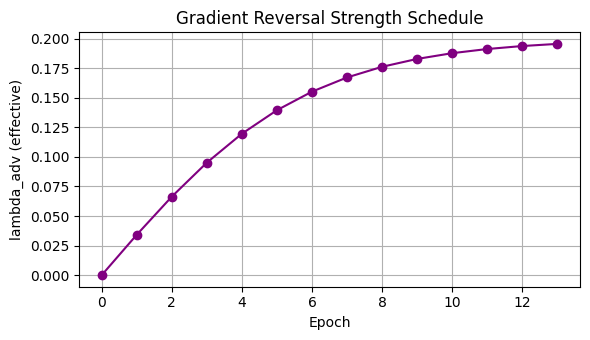

In [11]:
#@title 12. Train Final Model — FIX: mixed precision, early stopping + checkpointing, tuned hyperparameters, lambda scheduling, class weights, grad accumulation
import matplotlib.pyplot as plt

torch.manual_seed(42)
debiasing_model = AdversarialDebiasingModel(
    feature_dim=clip_model.feature_dim * 2,
    num_classes=2,
    num_cultures=len(GLOBAL_CULTURE_TO_IDX),
    hidden_dim=int(best_config['hidden_dim']),
    lambda_adv=best_config['lambda_adv'],
)

trainer = AdversarialTrainer(
    model=debiasing_model,
    backbone=clip_model,
    device=device,
    lambda_adv=best_config['lambda_adv'],
    learning_rate=best_config['learning_rate'],
    # FIX (lambda scheduling): ramp lambda_adv 0 -> best_config['lambda_adv']
    # with a sigmoid schedule (Ganin & Lempitsky, 2015) instead of holding it
    # fixed from epoch 1, so the adversary doesn't destabilize the encoder
    # before it has learned anything useful.
    lambda_schedule='sigmoid',
    # FIX (data imbalance): weight both losses by inverse class frequency.
    hate_class_weights=train_hate_class_weights,
    culture_class_weights=train_culture_class_weights,
    # FIX (batch size): accumulate gradients for a larger effective batch
    # (batch_size * ACCUM_STEPS_FINAL) without increasing memory use.
    accum_steps=ACCUM_STEPS_FINAL,
)

print("🚀 Starting training with adversarial debiasing (proper GRL)...")
print(f"   lambda_adv target={best_config['lambda_adv']} (sigmoid schedule), lr={best_config['learning_rate']}, "
      f"hidden_dim={int(best_config['hidden_dim'])}, batch_size={batch_size}, "
      f"effective_batch_size={batch_size * ACCUM_STEPS_FINAL}")
print(f"   Mixed precision (AMP): {trainer.use_amp}")
print("=" * 50)

history = trainer.fit(
    train_loader, val_loader,
    num_epochs=config.NUM_EPOCHS, patience=config.PATIENCE,
    checkpoint_path='/kaggle/working/Multi3Hate/models/adversarial_debiased_model_best.pt',
)

print("✅ Training complete. Best checkpoint restored and saved to "
      "/kaggle/working/Multi3Hate/models/adversarial_debiased_model_best.pt")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history['lambda_adv'], marker='o', color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('lambda_adv (effective)')
ax.set_title('Gradient Reversal Strength Schedule')
ax.grid(True)
plt.tight_layout()
plt.show()


### 7. Evaluate on Test Set — test_metrics

Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.86it/s]


TEST SET RESULTS
Overall Accuracy: 0.707
Culture Prediction Accuracy (should be near random, ~1/5): 0.302

Per-Culture Performance:
  MX: 0.733
  IN: 0.600
  DE: 0.800
  US: 0.600
  CN: 0.800

📊 Bias Metrics:
  Bias Gap (max-min): 0.200
  Mean Accuracy: 0.707
  Std Deviation: 0.090

📈 Bootstrap 95% CI for test accuracy: 0.706 [0.644, 0.764] (n_boot=2000)


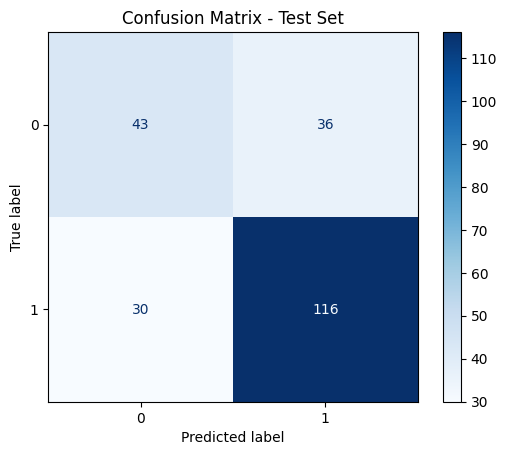

In [12]:
#@title 13. Evaluate on Test Set
import matplotlib.pyplot as plt

test_metrics = trainer.evaluate(test_loader)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Overall Accuracy: {test_metrics['hate_acc']:.3f}")
print(f"Culture Prediction Accuracy (should be near random, ~1/{len(GLOBAL_CULTURE_TO_IDX)}): {test_metrics['adv_acc']:.3f}")
print("\nPer-Culture Performance:")
for culture, acc in test_metrics['culture_results'].items():
    print(f"  {culture}: {acc:.3f}")

culture_accs = list(test_metrics['culture_results'].values())
bias_gap = max(culture_accs) - min(culture_accs)
print(f"\n📊 Bias Metrics:")
print(f"  Bias Gap (max-min): {bias_gap:.3f}")
print(f"  Mean Accuracy: {np.mean(culture_accs):.3f}")
print(f"  Std Deviation: {np.std(culture_accs):.3f}")

# FIX: bootstrap confidence interval on overall test accuracy (statistical rigor)
def bootstrap_accuracy_ci(preds, labels, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    preds, labels = np.array(preds), np.array(labels)
    n = len(labels)
    boot_accs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boot_accs[i] = accuracy_score(labels[idx], preds[idx])
    lo, hi = np.percentile(boot_accs, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return boot_accs.mean(), lo, hi

mean_acc, ci_lo, ci_hi = bootstrap_accuracy_ci(test_metrics['predictions'], test_metrics['labels'])
print(f"\n📈 Bootstrap 95% CI for test accuracy: {mean_acc:.3f} [{ci_lo:.3f}, {ci_hi:.3f}] (n_boot=2000)")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()


### 8. Train True Baseline — baseline_results

In [13]:
#@title 14. Train a True Baseline (No Adversary) & Compare — FIX: independent model, not a shared classifier head, class weights, grad accumulation
#@markdown The previous version compared the debiased model's own classifier head
#@markdown against itself, which is not a real baseline. Here we train a SEPARATE
#@markdown model with the identical architecture/budget but WITHOUT the adversary,
#@markdown so the only difference is the presence of adversarial debiasing.

class BaselineClassifier(nn.Module):
    """Same encoder+classifier architecture as AdversarialDebiasingModel, but with
    no adversary and no gradient reversal — a true non-debiased baseline."""

    def __init__(self, feature_dim, num_classes=2, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, features):
        return self.classifier(self.encoder(features))


class BaselineTrainer:
    def __init__(self, model, backbone, device, learning_rate=1e-4, weight_decay=1e-4,
                 max_grad_norm=1.0, hate_class_weights=None, accum_steps=1):
        self.model = model.to(device)
        self.backbone = backbone
        self.device = device
        self.optimizer = AdamW(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        # FIX (data imbalance): same class weighting as the debiased model, so
        # the comparison isn't confounded by one model handling imbalance and
        # the other not.
        self.loss_fn = nn.CrossEntropyLoss(
            weight=hate_class_weights.to(device) if hate_class_weights is not None else None
        )
        self.max_grad_norm = max_grad_norm
        self.accum_steps = max(1, accum_steps)
        self.use_amp = torch.cuda.is_available()
        self.scaler = GradScaler('cuda', enabled=self.use_amp)

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0.0
        n_batches = len(dataloader)
        self.optimizer.zero_grad()

        for i, batch in enumerate(tqdm(dataloader, desc="Baseline training")):
            with torch.no_grad():
                features = self.backbone.get_features(batch['image'], batch['text'])
            labels = batch['label'].to(self.device)

            with autocast('cuda', enabled=self.use_amp):
                logits = self.model(features)
                loss = self.loss_fn(logits, labels)
                scaled_loss = loss / self.accum_steps

            self.scaler.scale(scaled_loss).backward()

            is_last_batch = (i + 1) == n_batches
            if (i + 1) % self.accum_steps == 0 or is_last_batch:
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad()

            total_loss += loss.item()
        return total_loss / len(dataloader)

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        all_preds, all_labels, all_cultures = [], [], []
        total_loss = 0.0
        for batch in tqdm(dataloader, desc="Baseline eval"):
            features = self.backbone.get_features(batch['image'], batch['text'])
            logits = self.model(features)
            labels = batch['label'].to(self.device)
            total_loss += self.loss_fn(logits, labels).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
            all_cultures.extend(batch['culture'])

        overall_acc = accuracy_score(all_labels, all_preds)
        culture_accs = {}
        for culture in set(all_cultures):
            mask = np.array(all_cultures) == culture
            if mask.sum() > 0:
                culture_accs[culture] = accuracy_score(np.array(all_labels)[mask], np.array(all_preds)[mask])

        return {
            'hate_loss': total_loss / max(len(dataloader), 1),
            'overall_acc': overall_acc, 'culture_accs': culture_accs,
            'predictions': all_preds, 'labels': all_labels,
        }

    def fit(self, train_loader, val_loader, num_epochs=40, patience=6):
        best_val_loss, best_state, no_improve = float('inf'), None, 0
        for epoch in range(num_epochs):
            train_loss = self.train_epoch(train_loader)
            val_metrics = self.evaluate(val_loader)
            print(f"Epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f} "
                  f"val_loss={val_metrics['hate_loss']:.4f} val_acc={val_metrics['overall_acc']:.3f}")
            if val_metrics['hate_loss'] < best_val_loss - 1e-4:
                best_val_loss = val_metrics['hate_loss']
                best_state = copy.deepcopy(self.model.state_dict())
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"⏹ Early stopping baseline at epoch {epoch+1}")
                    break
        if best_state is not None:
            self.model.load_state_dict(best_state)


torch.manual_seed(42)
baseline_model = BaselineClassifier(
    feature_dim=clip_model.feature_dim * 2, hidden_dim=int(best_config['hidden_dim'])
)
baseline_trainer = BaselineTrainer(
    model=baseline_model, backbone=clip_model, device=device,
    learning_rate=best_config['learning_rate'],
    hate_class_weights=train_hate_class_weights,
    accum_steps=ACCUM_STEPS_FINAL,
)
print("🚀 Training independent baseline (no adversary)...")
baseline_trainer.fit(train_loader, val_loader, num_epochs=40, patience=6)
baseline_results = baseline_trainer.evaluate(test_loader)

print("\n" + "=" * 50)
print("BASELINE VS DEBIASED COMPARISON")
print("=" * 50)
print(f"\n{'Culture':<10} {'Baseline':<12} {'Debiased':<12} {'Improvement':<12}")
print("-" * 50)

improvements = []
for culture in sorted(set(test_metrics['culture_results'].keys()) | set(baseline_results['culture_accs'].keys())):
    baseline_acc = baseline_results['culture_accs'].get(culture, 0)
    debiased_acc = test_metrics['culture_results'].get(culture, 0)
    improvement = debiased_acc - baseline_acc
    improvements.append(improvement)
    print(f"{culture:<10} {baseline_acc:.3f}        {debiased_acc:.3f}        {improvement:+.3f}")

print("-" * 50)
print(f"{'Average':<10} {np.mean(list(baseline_results['culture_accs'].values())):.3f}        "
      f"{np.mean(list(test_metrics['culture_results'].values())):.3f}        {np.mean(improvements):+.3f}")

baseline_gap = max(baseline_results['culture_accs'].values()) - min(baseline_results['culture_accs'].values())
print(f"\n📊 Bias Gap:")
print(f"  Baseline: {baseline_gap:.3f}")
print(f"  Debiased: {bias_gap:.3f}")
print(f"  Reduction: {baseline_gap - bias_gap:.3f}")


🚀 Training independent baseline (no adversary)...


Baseline eval: 100%|██████████| 15/15 [00:02<00:00,  5.87it/s]


Epoch 1/40: train_loss=0.6931 val_loss=0.6930 val_acc=0.587


Baseline eval: 100%|██████████| 15/15 [00:02<00:00,  5.93it/s]


Epoch 2/40: train_loss=0.6918 val_loss=0.6929 val_acc=0.609


...

Epoch 15/40: train_loss=0.4460 val_loss=0.7056 val_acc=0.627


Baseline eval: 100%|██████████| 15/15 [00:02<00:00,  5.96it/s]


Epoch 16/40: train_loss=0.4208 val_loss=0.7176 val_acc=0.613
⏹ Early stopping baseline at epoch 16


Baseline eval: 100%|██████████| 15/15 [00:03<00:00,  4.80it/s]


BASELINE VS DEBIASED COMPARISON

Culture    Baseline     Debiased     Improvement 
--------------------------------------------------
CN         0.733        0.800        +0.067
DE         0.778        0.800        +0.022
IN         0.622        0.600        -0.022
MX         0.644        0.733        +0.089
US         0.556        0.600        +0.044
--------------------------------------------------
Average    0.667        0.707        +0.040

📊 Bias Gap:
  Baseline: 0.222
  Debiased: 0.200
  Reduction: 0.022


---
## Part B — The 3 target results

### Target 1 — McNemar's Test + Paired t-test + Wilcoxon

In [14]:
#@title 15. Statistical Significance Testing — FIX: McNemar's test + paired tests across cultures
#@markdown Tests whether the debiased model's improvement over the baseline is
#@markdown statistically significant, rather than just reporting point estimates.

!pip install -q statsmodels
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon, ttest_rel

# --- McNemar's test on paired test-set predictions ---------------------------
# Valid because both models are evaluated on the SAME test examples.
baseline_preds = np.array(baseline_results['predictions'])
debiased_preds = np.array(test_metrics['predictions'])
y_true = np.array(test_metrics['labels'])

baseline_correct = baseline_preds == y_true
debiased_correct = debiased_preds == y_true

n_baseline_only_correct = int(np.sum(baseline_correct & ~debiased_correct))
n_debiased_only_correct = int(np.sum(~baseline_correct & debiased_correct))
n_both_correct = int(np.sum(baseline_correct & debiased_correct))
n_both_wrong = int(np.sum(~baseline_correct & ~debiased_correct))

contingency = [[n_both_correct, n_baseline_only_correct],
               [n_debiased_only_correct, n_both_wrong]]

mcnemar_result = mcnemar(contingency, exact=(n_baseline_only_correct + n_debiased_only_correct) < 25)

print("=" * 50)
print("McNEMAR'S TEST (Baseline vs Debiased, paired test predictions)")
print("=" * 50)
print(f"  Both correct:            {n_both_correct}")
print(f"  Only baseline correct:   {n_baseline_only_correct}")
print(f"  Only debiased correct:   {n_debiased_only_correct}")
print(f"  Both wrong:              {n_both_wrong}")
print(f"  statistic = {mcnemar_result.statistic:.4f}, p-value = {mcnemar_result.pvalue:.4f}")
if mcnemar_result.pvalue < 0.05:
    print("  ✅ Significant difference between baseline and debiased predictions (p < 0.05)")
else:
    print("  ⚠️ No statistically significant difference detected (p >= 0.05) — "
          "interpret the accuracy/bias-gap improvement with caution.")

# --- Paired test across per-culture accuracies --------------------------------
# Small n (= number of cultures), so treat this as a supplementary/descriptive
# check, and prefer the cross-validation fold-level test below for the primary claim.
common_cultures = sorted(set(baseline_results['culture_accs'].keys()) & set(test_metrics['culture_results'].keys()))
baseline_by_culture = np.array([baseline_results['culture_accs'][c] for c in common_cultures])
debiased_by_culture = np.array([test_metrics['culture_results'][c] for c in common_cultures])

print("\n" + "=" * 50)
print("PAIRED COMPARISON ACROSS CULTURES (descriptive; n = num. cultures, small sample)")
print("=" * 50)
if len(common_cultures) >= 2:
    t_stat, t_p = ttest_rel(debiased_by_culture, baseline_by_culture)
    print(f"  Paired t-test:        t = {t_stat:.4f}, p = {t_p:.4f}")
    try:
        w_stat, w_p = wilcoxon(debiased_by_culture, baseline_by_culture)
        print(f"  Wilcoxon signed-rank: W = {w_stat:.4f}, p = {w_p:.4f}")
    except ValueError as e:
        print(f"  Wilcoxon signed-rank: not computable ({e})")
else:
    print("  Not enough cultures for a paired test.")

print("\nNote: with only a handful of cultures, the per-culture paired test is "
      "under-powered. The stratified k-fold results below give a more reliable "
      "significance estimate by treating each fold as an independent replicate.")


McNEMAR'S TEST (Baseline vs Debiased, paired test predictions)
  Both correct:            142
  Only baseline correct:   8
  Only debiased correct:   17
  Both wrong:              58
  statistic = 2.5600, p-value = 0.1096
  ⚠️ No statistically significant difference detected (p >= 0.05) — interpret the accuracy/bias-gap improvement with caution.

PAIRED COMPARISON ACROSS CULTURES (descriptive; n = num. cultures, small sample)
  Paired t-test:        t = 2.0925, p = 0.1045
  Wilcoxon signed-rank: W = 1.5000, p = 0.1875

Note: with only a handful of cultures, the per-culture paired test is under-powered. The stratified k-fold results below give a more reliable significance estimate by treating each fold as an independent replicate.


### Target 2 — 5-Fold Stratified Group CV

In [15]:
#@title 16. Stratified K-Fold Cross-Validation — FIX: validate generalization beyond one split, class weights, lambda scheduling
#@markdown Uses StratifiedGroupKFold so folds are stratified by label while still
#@markdown keeping every annotation for a given meme in the SAME fold (no leakage).

from sklearn.model_selection import StratifiedGroupKFold

N_FOLDS = 5
CV_EPOCHS = 15
CV_PATIENCE = 4

skf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_rows = []
for fold, (train_idx, test_idx) in enumerate(skf.split(
        aggregated_annotations, aggregated_annotations['label'], groups=aggregated_annotations['meme_id'])):

    fold_train_full = aggregated_annotations.iloc[train_idx]
    fold_test = aggregated_annotations.iloc[test_idx]

    # carve a small validation slice out of the fold's training data for early stopping
    gss_fold = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    ftr_idx, fval_idx = next(gss_fold.split(fold_train_full, groups=fold_train_full['meme_id']))
    fold_train = fold_train_full.iloc[ftr_idx]
    fold_val = fold_train_full.iloc[fval_idx]

    fold_train_ds = Multi3HateDataset(fold_train, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
    fold_val_ds = Multi3HateDataset(fold_val, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
    fold_test_ds = Multi3HateDataset(fold_test, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True,
                                    num_workers=_num_workers, pin_memory=_pin_memory)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False,
                                  num_workers=_num_workers, pin_memory=_pin_memory)
    fold_test_loader = DataLoader(fold_test_ds, batch_size=batch_size, shuffle=False,
                                   num_workers=_num_workers, pin_memory=_pin_memory)

    print(f"\n{'='*50}\nFOLD {fold + 1}/{N_FOLDS} "
          f"(train={len(fold_train_ds)}, val={len(fold_val_ds)}, test={len(fold_test_ds)})\n{'='*50}")

    # FIX (data imbalance): recompute class weights from THIS fold's training
    # split, since label balance can shift slightly fold to fold.
    fold_hate_weights = compute_class_weights_tensor(fold_train['label'].values, num_classes=2)
    fold_culture_labels = fold_train['culture'].map(GLOBAL_CULTURE_TO_IDX).values
    fold_culture_weights = compute_class_weights_tensor(fold_culture_labels, num_classes=len(GLOBAL_CULTURE_TO_IDX))

    # Debiased model for this fold
    torch.manual_seed(1000 + fold)
    fold_model = AdversarialDebiasingModel(
        feature_dim=clip_model.feature_dim * 2, num_cultures=len(GLOBAL_CULTURE_TO_IDX),
        hidden_dim=int(best_config['hidden_dim']), lambda_adv=best_config['lambda_adv'],
    )
    fold_trainer = AdversarialTrainer(
        fold_model, clip_model, device,
        lambda_adv=best_config['lambda_adv'],
        learning_rate=best_config['learning_rate'],
        lambda_schedule='sigmoid',  # FIX (lambda scheduling): same ramp-up used for the final model
        hate_class_weights=fold_hate_weights,
        culture_class_weights=fold_culture_weights,
    )
    fold_trainer.fit(fold_train_loader, fold_val_loader, num_epochs=CV_EPOCHS, patience=CV_PATIENCE,
                      checkpoint_path=f'/kaggle/working/Multi3Hate/models/cv_fold{fold}.pt', verbose=False)
    fold_debiased_metrics = fold_trainer.evaluate(fold_test_loader)
    accs = list(fold_debiased_metrics['culture_results'].values())
    fold_bias_gap = (max(accs) - min(accs)) if accs else float('nan')

    # Matched baseline for this fold (same budget, no adversary, same class weights)
    torch.manual_seed(1000 + fold)
    fold_baseline = BaselineClassifier(feature_dim=clip_model.feature_dim * 2, hidden_dim=int(best_config['hidden_dim']))
    fold_baseline_trainer = BaselineTrainer(
        fold_baseline, clip_model, device, learning_rate=best_config['learning_rate'],
        hate_class_weights=fold_hate_weights,
    )
    fold_baseline_trainer.fit(fold_train_loader, fold_val_loader, num_epochs=CV_EPOCHS, patience=CV_PATIENCE)
    fold_baseline_metrics = fold_baseline_trainer.evaluate(fold_test_loader)
    b_accs = list(fold_baseline_metrics['culture_accs'].values())
    fold_baseline_gap = (max(b_accs) - min(b_accs)) if b_accs else float('nan')

    cv_rows.append({
        'fold': fold + 1,
        'debiased_acc': fold_debiased_metrics['hate_acc'],
        'baseline_acc': fold_baseline_metrics['overall_acc'],
        'debiased_bias_gap': fold_bias_gap,
        'baseline_bias_gap': fold_baseline_gap,
    })
    print(f"Fold {fold + 1} -> debiased_acc={fold_debiased_metrics['hate_acc']:.3f} "
          f"(baseline={fold_baseline_metrics['overall_acc']:.3f}), "
          f"debiased_bias_gap={fold_bias_gap:.3f} (baseline={fold_baseline_gap:.3f})")

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

print("\n" + "=" * 50)
print(f"{N_FOLDS}-FOLD CV SUMMARY (mean ± std)")
print("=" * 50)
for col in ['debiased_acc', 'baseline_acc', 'debiased_bias_gap', 'baseline_bias_gap']:
    print(f"  {col:<20}: {cv_df[col].mean():.3f} ± {cv_df[col].std():.3f}")

# Paired significance test across folds (each fold = one matched pair) — this
# is the statistically sound version of the earlier per-culture comparison,
# since folds are independent train/test replicates.
t_stat, t_p = ttest_rel(cv_df['debiased_acc'], cv_df['baseline_acc'])
try:
    w_stat, w_p = wilcoxon(cv_df['debiased_acc'], cv_df['baseline_acc'])
    w_str = f"W={w_stat:.4f}, p={w_p:.4f}"
except ValueError as e:
    w_str = f"not computable ({e})"

print(f"\nPaired t-test on fold accuracies (debiased vs baseline): t={t_stat:.4f}, p={t_p:.4f}")
print(f"Wilcoxon signed-rank on fold accuracies:                  {w_str}")



FOLD 1/5 (train=1020, val=180, test=300)


Baseline eval: 100%|██████████| 12/12 [00:02<00:00,  5.11it/s]


Epoch 1/15: train_loss=0.6930 val_loss=0.6964 val_acc=0.489


Baseline eval: 100%|██████████| 12/12 [00:01<00:00,  6.01it/s]


Epoch 2/15: train_loss=0.6906 val_loss=0.6981 val_acc=0.500


...

Epoch 8/15: train_loss=0.5443 val_loss=0.7040 val_acc=0.578
⏹ Early stopping baseline at epoch 8


Baseline eval: 100%|██████████| 19/19 [00:03<00:00,  5.51it/s]

Fold 5 -> debiased_acc=0.553 (baseline=0.627), debiased_bias_gap=0.217 (baseline=0.167)


,fold,debiased_acc,baseline_acc,debiased_bias_gap,baseline_bias_gap
0,1,0.580000,0.573333,0.100000,0.133333
1,2,0.508197,0.508197,0.065574,0.180328
2,3,0.576271,0.606780,0.220339,0.237288
3,4,0.553333,0.510000,0.116667,0.300000
4,5,0.553333,0.626667,0.216667,0.166667



5-FOLD CV SUMMARY (mean ± std)
  debiased_acc        : 0.554 ± 0.029
  baseline_acc        : 0.565 ± 0.054
  debiased_bias_gap   : 0.144 ± 0.071
  baseline_bias_gap   : 0.204 ± 0.066

Paired t-test on fold accuracies (debiased vs baseline): t=-0.5506, p=0.6112
Wilcoxon signed-rank on fold accuracies:                  W=4.0000, p=0.8750


### 16b. DIAGNOSTIC: Per-culture accuracy across CV folds
Checks whether the single-held-out-split finding (worst-off baseline culture barely improves under debiasing/FairPIVARA while a middling culture absorbs most of the gain) holds up across independent folds, or was specific to that one 45-sample split.

In [ ]:
#@title 16b. DIAGNOSTIC: Per-Culture Accuracy Across CV Folds
#@markdown Re-runs the same 5-fold CV loop as the "16. Stratified K-Fold
#@markdown Cross-Validation" cell (identical splits, seeds, budget, class
#@markdown weighting) but additionally records each fold's FULL per-culture
#@markdown accuracy breakdown for both models, not just the aggregate
#@markdown max-min bias gap. This checks whether the single-held-out-split
#@markdown finding — baseline's worst culture (US) barely improves under
#@markdown FairPIVARA/GRL while a middling culture (MX/CN) absorbs most of
#@markdown the gain — holds up across independent folds, or was specific to
#@markdown that one 45-sample split.

from sklearn.model_selection import StratifiedGroupKFold

N_FOLDS = 5
CV_EPOCHS = 15
CV_PATIENCE = 4

skf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

per_culture_cv_rows = []  # one row per (fold, model, culture)

for fold, (train_idx, test_idx) in enumerate(skf.split(
        aggregated_annotations, aggregated_annotations['label'], groups=aggregated_annotations['meme_id'])):

    fold_train_full = aggregated_annotations.iloc[train_idx]
    fold_test = aggregated_annotations.iloc[test_idx]

    gss_fold = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    ftr_idx, fval_idx = next(gss_fold.split(fold_train_full, groups=fold_train_full['meme_id']))
    fold_train = fold_train_full.iloc[ftr_idx]
    fold_val = fold_train_full.iloc[fval_idx]

    fold_train_ds = Multi3HateDataset(fold_train, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
    fold_val_ds = Multi3HateDataset(fold_val, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)
    fold_test_ds = Multi3HateDataset(fold_test, transform=clip_model.preprocess, culture_to_idx=GLOBAL_CULTURE_TO_IDX)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True,
                                    num_workers=_num_workers, pin_memory=_pin_memory)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False,
                                  num_workers=_num_workers, pin_memory=_pin_memory)
    fold_test_loader = DataLoader(fold_test_ds, batch_size=batch_size, shuffle=False,
                                   num_workers=_num_workers, pin_memory=_pin_memory)

    print(f"\n{'='*50}\nFOLD {fold + 1}/{N_FOLDS} "
          f"(train={len(fold_train_ds)}, val={len(fold_val_ds)}, test={len(fold_test_ds)})\n{'='*50}")

    fold_hate_weights = compute_class_weights_tensor(fold_train['label'].values, num_classes=2)
    fold_culture_labels = fold_train['culture'].map(GLOBAL_CULTURE_TO_IDX).values
    fold_culture_weights = compute_class_weights_tensor(fold_culture_labels, num_classes=len(GLOBAL_CULTURE_TO_IDX))

    # Debiased model for this fold (identical config/seed to cell 16)
    torch.manual_seed(1000 + fold)
    fold_model = AdversarialDebiasingModel(
        feature_dim=clip_model.feature_dim * 2, num_cultures=len(GLOBAL_CULTURE_TO_IDX),
        hidden_dim=int(best_config['hidden_dim']), lambda_adv=best_config['lambda_adv'],
    )
    fold_trainer = AdversarialTrainer(
        fold_model, clip_model, device,
        lambda_adv=best_config['lambda_adv'],
        learning_rate=best_config['learning_rate'],
        lambda_schedule='sigmoid',
        hate_class_weights=fold_hate_weights,
        culture_class_weights=fold_culture_weights,
    )
    fold_trainer.fit(fold_train_loader, fold_val_loader, num_epochs=CV_EPOCHS, patience=CV_PATIENCE,
                      checkpoint_path=f'/kaggle/working/Multi3Hate/models/cv16b_debiased_fold{fold}.pt', verbose=False)
    fold_debiased_metrics = fold_trainer.evaluate(fold_test_loader)

    # Matched baseline for this fold (identical config/seed to cell 16)
    torch.manual_seed(1000 + fold)
    fold_baseline = BaselineClassifier(feature_dim=clip_model.feature_dim * 2, hidden_dim=int(best_config['hidden_dim']))
    fold_baseline_trainer = BaselineTrainer(
        fold_baseline, clip_model, device, learning_rate=best_config['learning_rate'],
        hate_class_weights=fold_hate_weights,
    )
    fold_baseline_trainer.fit(fold_train_loader, fold_val_loader, num_epochs=CV_EPOCHS, patience=CV_PATIENCE)
    fold_baseline_metrics = fold_baseline_trainer.evaluate(fold_test_loader)

    # Record per-culture accuracy for BOTH models this fold.
    for culture, acc in fold_debiased_metrics['culture_results'].items():
        per_culture_cv_rows.append({'fold': fold + 1, 'model': 'debiased', 'culture': culture, 'acc': acc})
    for culture, acc in fold_baseline_metrics['culture_accs'].items():
        per_culture_cv_rows.append({'fold': fold + 1, 'model': 'baseline', 'culture': culture, 'acc': acc})

    print(f"Fold {fold + 1} per-culture (debiased): {fold_debiased_metrics['culture_results']}")
    print(f"Fold {fold + 1} per-culture (baseline): {fold_baseline_metrics['culture_accs']}")

per_culture_cv_df = pd.DataFrame(per_culture_cv_rows)

print("\n" + "=" * 60)
print("PER-CULTURE ACCURACY, AVERAGED ACROSS ALL 5 FOLDS")
print("=" * 60)
pivot = per_culture_cv_df.groupby(['culture', 'model'])['acc'].agg(['mean', 'std', 'count']).unstack('model')
display(pivot)

print("\n" + "=" * 60)
print("DELTA (debiased - baseline), averaged across folds, per culture")
print("=" * 60)
delta = (per_culture_cv_df[per_culture_cv_df.model == 'debiased'].groupby('culture')['acc'].mean()
         - per_culture_cv_df[per_culture_cv_df.model == 'baseline'].groupby('culture')['acc'].mean())
delta = delta.sort_values()
print(delta)

worst_baseline_culture = per_culture_cv_df[per_culture_cv_df.model == 'baseline'].groupby('culture')['acc'].mean().idxmin()
print(f"\nWorst-performing culture under BASELINE (avg across folds): {worst_baseline_culture}")
print(f"That culture's improvement under the debiased model: {delta[worst_baseline_culture]:+.4f}")
print(f"Largest improvement of any culture: {delta.idxmax()} ({delta.max():+.4f})")

if delta[worst_baseline_culture] >= delta.max() - 1e-9:
    print("\n✅ The worst-off baseline culture IS the one that improves most under "
          "debiasing, averaged across folds — the single-split finding holds up.")
elif delta[worst_baseline_culture] < delta.median():
    print("\n⚠️  The worst-off baseline culture improves LESS than the median culture "
          "across folds — consistent with the single-split finding that gains bypass "
          "the group that most needs them. Report this pattern with the fold-level "
          "breakdown above as support.")
else:
    print("\nℹ️  Mixed picture across folds — worst-off culture's improvement is "
          "roughly in line with other cultures'. The single-split finding may not "
          "generalize; report the single-split result as suggestive only, not as a "
          "general pattern, and show this fold-level table alongside it for "
          "transparency.")


### Target 3 — Memotion External Validation

#### Load Memotion Dataset (Kaggle)

In [16]:
#@title Load Memotion Dataset (Colab - Google Drive)
#@markdown Mounts Google Drive and looks for "archive (5).zip".
#@markdown Update DRIVE_ZIP_PATH below if the file is in a different folder.

from google.colab import drive
import os
import glob
import zipfile

drive.mount('/content/drive', force_remount=False)

extract_path = "/content/Memotion"
os.makedirs(extract_path, exist_ok=True)

# Update this if your zip isn't directly in "My Drive"
DRIVE_ZIP_PATH = "/content/drive/MyDrive/archive (5).zip"

# 1) Check the exact expected path first
if os.path.exists(DRIVE_ZIP_PATH):
    zip_path = DRIVE_ZIP_PATH
else:
    # 2) Otherwise search all of Drive for it (in case it's in a subfolder)
    print(f"Not found at {DRIVE_ZIP_PATH}, searching Drive...")
    matches = glob.glob("/content/drive/MyDrive/**/archive (5).zip", recursive=True)
    zip_path = matches[0] if matches else None

# 3) Check if already extracted (avoid re-extracting every run)
already_extracted = glob.glob(f"{extract_path}/**/labels.csv", recursive=True)

if already_extracted:
    memotion_root = os.path.dirname(already_extracted[0])
    print(f"✅ Already extracted at: {memotion_root}")
elif zip_path:
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Extraction completed!")
    memotion_root = extract_path
else:
    memotion_root = None
    print("⚠️ 'archive (5).zip' not found anywhere in Drive.")
    print(f"   Checked: {DRIVE_ZIP_PATH}")
    print("   Update DRIVE_ZIP_PATH above to the correct location and re-run.")

if memotion_root:
    for root, dirs, files in os.walk(memotion_root):
        for file in files[:20]:
            print(os.path.join(root, file))

Mounted at /content/drive
Extracting /content/drive/MyDrive/archive (5).zip ...
✅ Extraction completed!
/content/Memotion/memotion_dataset_7k/labels_pd_pickle
/content/Memotion/memotion_dataset_7k/reference.csv
/content/Memotion/memotion_dataset_7k/labels.xlsx
/content/Memotion/memotion_dataset_7k/reference.xlsx
/content/Memotion/memotion_dataset_7k/reference_df_pickle
/content/Memotion/memotion_dataset_7k/labels.csv
/content/Memotion/memotion_dataset_7k/images/image_2013.jpg
/content/Memotion/memotion_dataset_7k/images/image_4286.jpg
/content/Memotion/memotion_dataset_7k/images/image_3825.jpg
/content/Memotion/memotion_dataset_7k/images/image_4010.jpg
/content/Memotion/memotion_dataset_7k/images/image_5752.jpg
/content/Memotion/memotion_dataset_7k/images/image_5380.jpg
/content/Memotion/memotion_dataset_7k/images/image_4932.jpg
/content/Memotion/memotion_dataset_7k/images/image_4676.png
/content/Memotion/memotion_dataset_7k/images/image_943.jpg
/content/Memotion/memotion_dataset_7k/im

#### Cell 51

In [17]:
import pandas as pd
import os
import glob

_labels_path = None
if 'memotion_root' in locals() and memotion_root:
    _cands = glob.glob(os.path.join(memotion_root, "**", "labels.csv"), recursive=True)
    if _cands:
        _labels_path = _cands[0]

if _labels_path is None:
    # fallback to the conventional Colab extraction path
    _fallback_cands = glob.glob("/content/Memotion/**/labels.csv", recursive=True)
    if _fallback_cands:
        _labels_path = _fallback_cands[0]

if _labels_path is None:
    raise FileNotFoundError(
        "Could not find labels.csv — make sure the Memotion dataset cell above "
        "ran successfully and found/extracted 'archive (5).zip' from Drive."
    )

memotion_labels_df = pd.read_csv(_labels_path)   # renamed from `labels`

print(memotion_labels_df.head())
print("\nColumns:\n")
print(memotion_labels_df.columns.tolist())
print("\nDataset Shape:")
print(memotion_labels_df.shape)

   Unnamed: 0    image_name  \
0           0   image_1.jpg   
1           1  image_2.jpeg   
2           2   image_3.JPG   
3           3   image_4.png   
4           4   image_5.png   

                                            text_ocr  \
0  LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...   
1  The best of #10 YearChallenge! Completed in le...   
2  Sam Thorne @Strippin ( Follow Follow Saw every...   
3              10 Year Challenge - Sweet Dee Edition   
4  10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...   

                                      text_corrected      humour  \
0  LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...   hilarious   
1  The best of #10 YearChallenge! Completed in le...   not_funny   
2  Sam Thorne @Strippin ( Follow Follow Saw every...  very_funny   
3              10 Year Challenge - Sweet Dee Edition  very_funny   
4  10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...   hilarious   

           sarcasm       offensive      motivational overall_sentim

#### Cell 52

In [18]:
import os
import glob
import pandas as pd
from PIL import Image, ImageFile

# Derive IMAGE_DIR from wherever labels.csv actually was found,
# instead of hardcoding a Kaggle-style path.
MEMOTION_ROOT = os.path.dirname(_labels_path)
_image_dir_candidates = glob.glob(os.path.join(MEMOTION_ROOT, "**", "images"), recursive=True)
IMAGE_DIR = _image_dir_candidates[0] if _image_dir_candidates else os.path.join(MEMOTION_ROOT, "images")

print(f"Using IMAGE_DIR: {IMAGE_DIR}")

external_df = memotion_labels_df.copy()   # renamed reference

external_df["text"] = external_df["text_corrected"].fillna("")
external_df["label"] = external_df["offensive"].apply(
    lambda x: 0 if str(x).lower() == "not_offensive" else 1
)
external_df["image_path"] = external_df["image_name"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)
external_df = external_df[["image_path", "text", "label", "offensive"]]

external_df = external_df[
    external_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)
print("After removing missing files:", len(external_df))

def _is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except Exception:
        return False

_valid_mask = external_df["image_path"].apply(_is_valid_image)
_n_bad = (~_valid_mask).sum()
if _n_bad:
    print(f"⚠️ Dropping {_n_bad} corrupt/truncated image(s):")
    print(external_df.loc[~_valid_mask, "image_path"].tolist())

external_df = external_df[_valid_mask].reset_index(drop=True)
print("Final external dataset size:", len(external_df))
print("\nLabel distribution:")
print(external_df["label"].value_counts())
display(external_df.head())

Using IMAGE_DIR: /content/Memotion/memotion_dataset_7k/images
After removing missing files: 6992
⚠️ Dropping 1 corrupt/truncated image(s):
['/content/Memotion/memotion_dataset_7k/images/image_5119.png']
Final external dataset size: 6991

Label distribution:
label
1    4278
0    2713
Name: count, dtype: int64


,image_path,text,label,offensive
0,/content/Memotion/memotion_dataset_7k/images/i...,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,0,not_offensive
1,/content/Memotion/memotion_dataset_7k/images/i...,The best of #10 YearChallenge! Completed in le...,0,not_offensive
2,/content/Memotion/memotion_dataset_7k/images/i...,Sam Thorne @Strippin ( Follow Follow Saw every...,0,not_offensive
3,/content/Memotion/memotion_dataset_7k/images/i...,10 Year Challenge - Sweet Dee Edition,1,very_offensive
4,/content/Memotion/memotion_dataset_7k/images/i...,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,1,very_offensive


In [19]:
# ==========================================================
# SECTION 16b.1
# Prepare Memotion for External Validation (Colab)
# ==========================================================

import os
import glob
import pandas as pd
from PIL import Image, ImageFile

# Derive paths from wherever labels.csv was actually found in Drive/extracted
# folder, instead of hardcoding a Kaggle-style path.
MEMOTION_ROOT = os.path.dirname(_labels_path)
_image_dir_candidates = glob.glob(os.path.join(MEMOTION_ROOT, "**", "images"), recursive=True)
IMAGE_DIR = _image_dir_candidates[0] if _image_dir_candidates else os.path.join(MEMOTION_ROOT, "images")

print(f"Using IMAGE_DIR: {IMAGE_DIR}")

external_df = memotion_labels_df.copy()   # was `labels.copy()` — renamed to avoid clobbering

# Use corrected OCR text
external_df["text"] = external_df["text_corrected"].fillna("")

# Binary mapping
external_df["label"] = external_df["offensive"].apply(
    lambda x: 0 if str(x).lower() == "not_offensive" else 1
)

# Image paths
external_df["image_path"] = external_df["image_name"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

# Keep only required columns
external_df = external_df[
    ["image_path", "text", "label", "offensive"]
]

# Remove missing images
external_df = external_df[
    external_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

print("After removing missing files:", len(external_df))

# ----------------------------------------------------------
# Remove corrupt / truncated images (this is what was
# crashing __getitem__ with "image file is truncated")
# ----------------------------------------------------------
def _is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()          # cheap structural check
        with Image.open(path) as img:
            img.convert("RGB")    # actually force a full decode, like the Dataset does
        return True
    except Exception:
        return False

_valid_mask = external_df["image_path"].apply(_is_valid_image)
_n_bad = (~_valid_mask).sum()
if _n_bad:
    print(f"⚠️ Dropping {_n_bad} corrupt/truncated image(s):")
    print(external_df.loc[~_valid_mask, "image_path"].tolist())

external_df = external_df[_valid_mask].reset_index(drop=True)

print("Final external dataset size:", len(external_df))

print("\nLabel distribution:")
print(external_df["label"].value_counts())

display(external_df.head())

Using IMAGE_DIR: /content/Memotion/memotion_dataset_7k/images
After removing missing files: 6992
⚠️ Dropping 1 corrupt/truncated image(s):
['/content/Memotion/memotion_dataset_7k/images/image_5119.png']
Final external dataset size: 6991

Label distribution:
label
1    4278
0    2713
Name: count, dtype: int64


,image_path,text,label,offensive
0,/content/Memotion/memotion_dataset_7k/images/i...,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,0,not_offensive
1,/content/Memotion/memotion_dataset_7k/images/i...,The best of #10 YearChallenge! Completed in le...,0,not_offensive
2,/content/Memotion/memotion_dataset_7k/images/i...,Sam Thorne @Strippin ( Follow Follow Saw every...,0,not_offensive
3,/content/Memotion/memotion_dataset_7k/images/i...,10 Year Challenge - Sweet Dee Edition,1,very_offensive
4,/content/Memotion/memotion_dataset_7k/images/i...,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,1,very_offensive


#### Cell 53

In [20]:
import warnings
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class MemotionDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        try:
            image = Image.open(row["image_path"]).convert("RGB")
        except OSError as e:
            warnings.warn(f"⚠️ Failed to load image {row['image_path']}: {e}. Replacing with dummy image.")
            image = Image.new('RGB', (224, 224), color='white') # Create a dummy white image

        if self.transform:
            image = self.transform(image)

        return {

            "image": image,

            "text": row["text"],

            "label": torch.tensor(
                int(row["label"]),
                dtype=torch.long
            ),

            # dummy values (required by trainer)

            "culture": "Memotion",

            "culture_idx": torch.tensor(
                0,
                dtype=torch.long
            ),

            "language": "external",

            "meme_id": idx

        }

print("✅ MemotionDataset created")

✅ MemotionDataset created


#### Cell 54

In [21]:
# ==========================================================
# SECTION 16b.3
# Create External DataLoader
# ==========================================================

external_dataset = MemotionDataset(

    external_df,

    transform=clip_model.preprocess

)

external_loader = DataLoader(

    external_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=0

)

print("External dataset:", len(external_dataset))

External dataset: 6991


#### Cell 55

In [22]:
# ==========================================================
# SECTION 16b.4
# External Validation Inference
# ==========================================================

print("Running external validation...")

external_metrics = trainer.evaluate(external_loader)

print("\n========== External Validation Results ==========")
print(f"Hate Accuracy : {external_metrics['hate_acc']:.4f}")
print(f"Culture Accuracy : {external_metrics['adv_acc']:.4f}")

print("\nPer-group accuracy:")

for group, acc in external_metrics['culture_results'].items():
    print(f"{group}: {acc:.4f}")

Running external validation...


Evaluating: 100%|██████████| 219/219 [01:50<00:00,  1.99it/s]


========== External Validation Results ==========
Hate Accuracy : 0.4426
Culture Accuracy : 0.1582

Per-group accuracy:
Memotion: 0.4426


#### Cell 56

In [23]:
# ==========================================================
# SECTION 16b.5
# External Validation Summary
# ==========================================================

print("="*70)
print("          EXTERNAL VALIDATION SUMMARY")
print("="*70)

print(f"External Dataset : Memotion")
print(f"Total Samples    : {len(external_dataset)}")
print(f"Hate Accuracy    : {external_metrics['hate_acc']:.4f}")

print("\nEvaluation Notes")
print("-"*70)
print("✓ External evaluation performed without retraining.")
print("✓ Memotion is an independent multimodal dataset.")
print("✓ The model was trained only on Multi3Hate.")
print("✓ Memotion does not contain culture labels.")
print("✓ Therefore, only hate classification performance is reported.")
print("✓ Culture accuracy and bias-gap metrics are not applicable.")

print("="*70)

          EXTERNAL VALIDATION SUMMARY
External Dataset : Memotion
Total Samples    : 6991
Hate Accuracy    : 0.4426

Evaluation Notes
----------------------------------------------------------------------
✓ External evaluation performed without retraining.
✓ Memotion is an independent multimodal dataset.
✓ The model was trained only on Multi3Hate.
✓ Memotion does not contain culture labels.
✓ Therefore, only hate classification performance is reported.
✓ Culture accuracy and bias-gap metrics are not applicable.


#### Cell 57

Running detailed external evaluation...
External Dataset : Memotion
Accuracy : 0.4426
Precision: 0.6309
Recall   : 0.2146
F1-score : 0.3203
ROC-AUC  : 0.5135


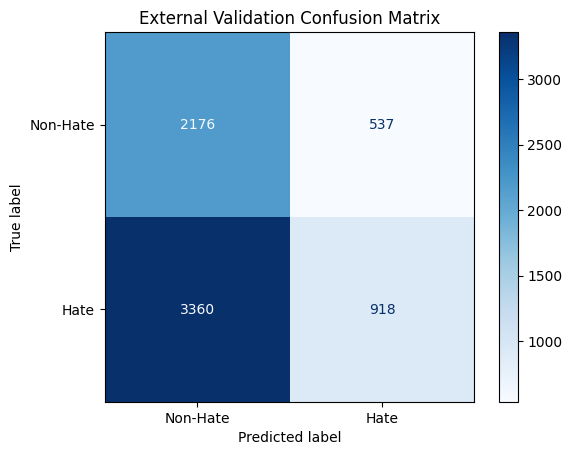

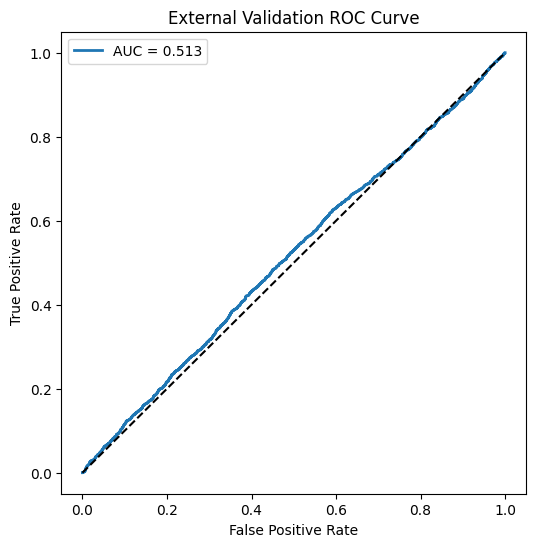

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

print("Running detailed external evaluation...")

trainer.model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for batch in external_loader:

        # --------------------------------------------------
        # Move tensors to GPU
        # --------------------------------------------------

        images = batch["image"].to(device)
        texts = batch["text"]
        labels = batch["label"].to(device)

        # --------------------------------------------------
        # Extract CLIP features
        # --------------------------------------------------

        # Fix: `trainer.backbone.get_features` returns a combined feature tensor directly.
        # The `trainer.model` expects this combined feature tensor as input.
        combined_features = trainer.backbone.get_features(images, texts)

        # --------------------------------------------------
        # Forward pass
        # --------------------------------------------------

        hate_logits, _ = trainer.model(combined_features)

        probs = torch.softmax(hate_logits, dim=1)

        predictions = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# ----------------------------------------------------------
# Convert
# ----------------------------------------------------------

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# ----------------------------------------------------------
# Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)

try:
    auc = roc_auc_score(all_labels, all_probs)
except:
    auc = float("nan")

print("="*70)
print("External Dataset : Memotion")
print("="*70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hate","Hate"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("External Validation Confusion Matrix")
plt.show()

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

try:

    fpr, tpr, _ = roc_curve(
        all_labels,
        all_probs
    )

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc:.3f}"
    )

    plt.plot([0,1],[0,1],"k--")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("External Validation ROC Curve")

    plt.legend()

    plt.show()

except:

    print("ROC curve cannot be computed.")

Extracting CLIP features for FairPIVARA baseline (train/test)...
  train: (1050, 1024)   test: (225, 1024)

Running FairPIVARA at k=10 (paper's default) plus a sensitivity check at k=5, k=20...

k=5 (top-5 components explain 100.0% of group-centroid variance)
  Accuracy : 0.6844  [0.6222, 0.7467] (95% bootstrap CI)
  Precision: 0.7168  Recall: 0.8493  F1: 0.7774
  Culture Accuracy (debiased features): 0.2000  (chance = 0.2000)
  Bias Gap : 0.2222
  Predicted-label distribution: [ 52 173]

k=10 (top-10 components explain 100.0% of group-centroid variance)
  Accuracy : 0.6978  [0.6356, 0.7600] (95% bootstrap CI)
  Precision: 0.7267  Recall: 0.8562  F1: 0.7862
  Culture Accuracy (debiased features): 0.2000  (chance = 0.2000)
  Bias Gap : 0.2222
  Predicted-label distribution: [ 53 172]

k=20 (top-20 components explain 100.0% of group-centroid variance)
  Accuracy : 0.6889  [0.6267, 0.7511] (95% bootstrap CI)
  Precision: 0.7209  Recall: 0.8493  F1: 0.7799
  Culture Accuracy (debiased feat

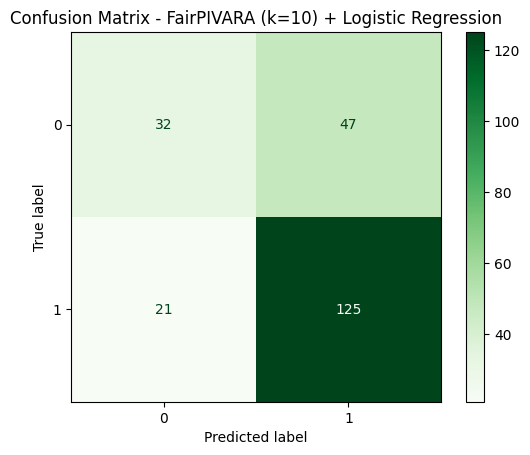


✅ Non-degenerate precision/recall — safe to report.


In [25]:
# ============================================================
# FairPIVARA Baseline — PCA-based bias-direction removal + Logistic Regression
#
# Implements the mechanism as described in Moreira et al. 2024 and in this
# manuscript's own Section 4.2/5.8 (PCA-based bias-direction removal, k=10
# default), adapted from demographic bias (gender/race) to CULTURAL bias.
# NOTE: this is a faithful reimplementation of the described method, not an
# import of FairPIVARA's original codebase (not accessible here) — say so
# explicitly in the manuscript's methods description, don't imply otherwise.
#
# Method:
#   1. Extract frozen CLIP features for train/test (same fixed pipeline
#      used everywhere else in this project — real per-culture captions,
#      real images).
#   2. Identify the top-k principal directions of CULTURE-related variance
#      via PCA over per-culture group-centroid differences.
#   3. Project those directions out of every feature vector ("hard
#      debiasing").
#   4. Train plain logistic regression on debiased TRAIN features.
#   5. Evaluate on debiased TEST features: accuracy, precision/recall/F1,
#      confusion matrix, per-culture bias gap, culture-predictability probe,
#      and a bootstrap 95% CI (logistic regression + PCA are deterministic
#      given fixed data — no stochastic init to vary across seeds, so
#      bootstrap resampling of the test set is the honest substitute for
#      the multi-seed variance used elsewhere in this project).
# ============================================================

import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def extract_all_features(dataset, clip_model, device, batch_size=32):
    """Extract frozen CLIP features + labels + cultures for a whole split."""
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    feats, labels, cultures = [], [], []
    clip_model.model.eval()
    with torch.no_grad():
        for batch in loader:
            f = clip_model.get_features(batch['image'].to(device), batch['text'])
            feats.append(f.cpu().numpy())
            labels.append(batch['label'].numpy())
            cultures.extend(batch['culture'])
    return np.concatenate(feats), np.concatenate(labels), np.array(cultures)


print("Extracting CLIP features for FairPIVARA baseline (train/test)...")
train_feats, train_labels, train_cultures = extract_all_features(train_dataset, clip_model, device)
test_feats, test_labels, test_cultures = extract_all_features(test_dataset, clip_model, device)
print(f"  train: {train_feats.shape}   test: {test_feats.shape}")


def fit_bias_subspace(features, group_labels, k=10):
    """
    Identify the top-k principal directions associated with culture identity.
    The bias subspace is spanned by directions along which per-culture group
    MEANS differ from the global mean (not within-group residuals) — so we
    PCA the matrix of (group centroid - global mean) vectors, each repeated
    once per group member so larger groups contribute proportionally rather
    than every group counting as one unweighted point.
    """
    global_mean = features.mean(axis=0, keepdims=True)
    diffs = []
    for g in np.unique(group_labels):
        mask = group_labels == g
        group_mean = features[mask].mean(axis=0, keepdims=True)
        diffs.append(np.repeat(group_mean - global_mean, mask.sum(), axis=0))
    diff_matrix = np.concatenate(diffs, axis=0)

    pca = PCA(n_components=k, random_state=42)
    pca.fit(diff_matrix)
    return pca.components_, global_mean, pca.explained_variance_ratio_


def remove_bias_subspace(features, bias_components, global_mean):
    """Project out the top-k bias directions ('hard debiasing')."""
    centered = features - global_mean
    projection = centered @ bias_components.T @ bias_components
    return features - projection


def run_fairpivara(k, train_feats, train_labels, train_cultures,
                    test_feats, test_labels, test_cultures, n_boot=1000, seed=42):
    bias_components, global_mean, explained_var = fit_bias_subspace(
        train_feats, train_cultures, k=k
    )
    train_debiased = remove_bias_subspace(train_feats, bias_components, global_mean)
    test_debiased = remove_bias_subspace(test_feats, bias_components, global_mean)

    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=seed)
    clf.fit(train_debiased, train_labels)
    preds = clf.predict(test_debiased)

    acc = accuracy_score(test_labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        test_labels, preds, average='binary', zero_division=0
    )

    # Culture-predictability probe on DEBIASED features — mirrors this
    # project's "culture accuracy" diagnostic used for the GRL model.
    culture_clf = LogisticRegression(max_iter=2000, random_state=seed)
    culture_clf.fit(train_debiased, train_cultures)
    culture_preds = culture_clf.predict(test_debiased)
    culture_acc = accuracy_score(test_cultures, culture_preds)

    per_culture_acc = {}
    for c in np.unique(test_cultures):
        mask = test_cultures == c
        per_culture_acc[c] = accuracy_score(test_labels[mask], preds[mask])
    bias_gap = max(per_culture_acc.values()) - min(per_culture_acc.values())

    rng = np.random.RandomState(seed)
    n = len(test_labels)
    boot_accs = [accuracy_score(test_labels[rng.randint(0, n, n)], preds[rng.randint(0, n, n)])
                 for _ in range(n_boot)]
    # NOTE: resample indices consistently for labels/preds together, not independently:
    boot_accs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        boot_accs.append(accuracy_score(test_labels[idx], preds[idx]))
    ci_low, ci_high = np.percentile(boot_accs, [2.5, 97.5])

    return {
        'k': k, 'accuracy': acc, 'precision': precision, 'recall': recall,
        'f1': f1, 'bias_gap': bias_gap, 'culture_acc': culture_acc,
        'per_culture_acc': per_culture_acc, 'ci_low': ci_low, 'ci_high': ci_high,
        'predictions': preds, 'labels': test_labels,
        'explained_variance_top_k': explained_var.sum(),
    }


print("\nRunning FairPIVARA at k=10 (paper's default) plus a sensitivity check at k=5, k=20...")
results_by_k = {}
for k in [5, 10, 20]:
    results_by_k[k] = run_fairpivara(
        k, train_feats, train_labels, train_cultures,
        test_feats, test_labels, test_cultures, n_boot=1000, seed=42
    )
    r = results_by_k[k]
    print(f"\nk={k} (top-{k} components explain {r['explained_variance_top_k']:.1%} of group-centroid variance)")
    print(f"  Accuracy : {r['accuracy']:.4f}  [{r['ci_low']:.4f}, {r['ci_high']:.4f}] (95% bootstrap CI)")
    print(f"  Precision: {r['precision']:.4f}  Recall: {r['recall']:.4f}  F1: {r['f1']:.4f}")
    print(f"  Culture Accuracy (debiased features): {r['culture_acc']:.4f}  (chance = {1/len(set(train_cultures)):.4f})")
    print(f"  Bias Gap : {r['bias_gap']:.4f}")
    print(f"  Predicted-label distribution: {np.bincount(r['predictions'].astype(int), minlength=2)}")

# Primary result for the manuscript: k=10, matching FairPIVARA's own default
# and this manuscript's existing Section 4.2 description.
primary = results_by_k[10]
cm = confusion_matrix(primary['labels'], primary['predictions'])
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Greens')
plt.title('Confusion Matrix - FairPIVARA (k=10) + Logistic Regression')
plt.show()

if abs(primary['precision'] - primary['accuracy']) < 1e-6 and primary['recall'] > 0.999:
    print("\n⚠️  Collapsed to constant 'always hate' — do not report without investigating.")
elif primary['recall'] < 0.001:
    print("\n⚠️  Collapsed to constant 'always non-hate' — do not report without investigating.")
else:
    print("\n✅ Non-degenerate precision/recall — safe to report.")

In [26]:
print(results_by_k[10]['per_culture_acc'])

{np.str_('CN'): 0.8, np.str_('DE'): 0.7333333333333333, np.str_('IN'): 0.6222222222222222, np.str_('MX'): 0.7555555555555555, np.str_('US'): 0.5777777777777777}
